# Install and Import Modules

In [1]:
!pip uninstall -y torch torchvision torchaudio torchcodec

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124


In [2]:
!pip3 install -q torch torchvision --index-url https://download.pytorch.org/whl/cu126
!pip install -q torchcodec==0.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 68.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 10.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install timm

In [4]:
# !pip install "ffmpeg<8"

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from datasets import load_dataset
from typing import Optional
from tensorflow import keras
from keras import layers
from keras import regularizers
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import cv2
import timm
from huggingface_hub import login

2025-10-19 11:30:49.773813: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760873450.188236    3327 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760873450.303520    3327 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `ty

In [2]:
login()

In [7]:
from torchcodec._frame import AudioSamples

In [8]:
import torchcodec
print("torchcodec version:", torchcodec.__version__)
import inspect
print("torchcodec module file:", inspect.getfile(torchcodec))


torchcodec version: 0.8.0
torchcodec module file: /usr/local/lib/python3.11/dist-packages/torchcodec/__init__.py


In [9]:
import torch
torch.__version__

'2.9.0+cu126'

# Load Data

In [3]:
dataset = load_dataset("nexar-ai/nexar_collision_prediction", split="train", drop_labels=False)

Resolving data files:   0%|          | 0/1502 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1348 [00:00<?, ?it/s]

In [4]:
dataset

Dataset({
    features: ['video', 'time_of_event', 'time_of_alert', 'light_conditions', 'weather', 'scene', 'time_to_accident'],
    num_rows: 1500
})

## Exploring Data

In [ ]:
def plot(frames: torch.Tensor, title : Optional[str] = None):
    """
    Plot a batch of frames.
    Args:
        frames: A batch of frames.
        title: A title for the plot.
    """
    try:
        from torchvision.utils import make_grid
        from torchvision.transforms.v2.functional import to_pil_image
        import matplotlib.pyplot as plt
    except ImportError:
        print("Cannot plot, please run `pip install torchvision matplotlib`")
        return

    plt.rcParams["savefig.bbox"] = 'tight'
    fig, ax = plt.subplots()
    ax.imshow(to_pil_image(make_grid(frames)))
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    if title is not None:
        ax.set_title(title)
    plt.tight_layout()

In [ ]:
decoder = dataset['video'][0]
time_of_event = dataset['time_of_event'][0]

In [ ]:
time_of_event

19.5

In [ ]:
print(decoder.metadata)

VideoStreamMetadata:
  duration_seconds_from_header: 40.466667
  begin_stream_seconds_from_header: 0.0
  bit_rate: 3442492.0
  codec: h264
  stream_index: 0
  begin_stream_seconds_from_content: 0.0
  end_stream_seconds_from_content: 40.466667
  width: 1280
  height: 720
  num_frames_from_header: 1214
  num_frames_from_content: 1214
  average_fps_from_header: 30.0
  pixel_aspect_ratio: 0
  duration_seconds: 40.466667
  begin_stream_seconds: 0.0
  end_stream_seconds: 40.466667
  num_frames: 1214
  average_fps: 29.99999975288303



In [ ]:
type(decoder)

torchcodec.decoders._video_decoder.VideoDecoder

In [ ]:
first_frame = decoder[0]  # using a single int index
every_twenty_frame = decoder[0 : -1 : 20]  # using slices

print(f"{first_frame.shape = }")
print(f"{first_frame.dtype = }")
print(f"{every_twenty_frame.shape = }")
print(f"{every_twenty_frame.dtype = }")

first_frame.shape = torch.Size([3, 720, 1280])
first_frame.dtype = torch.uint8
every_twenty_frame.shape = torch.Size([61, 3, 720, 1280])
every_twenty_frame.dtype = torch.uint8


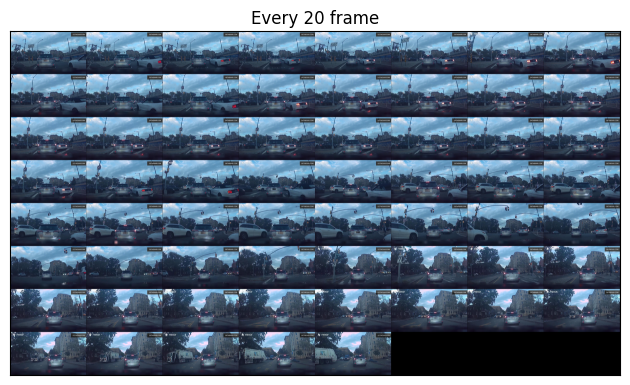

In [ ]:
plot(every_twenty_frame, "Every 20 frame")

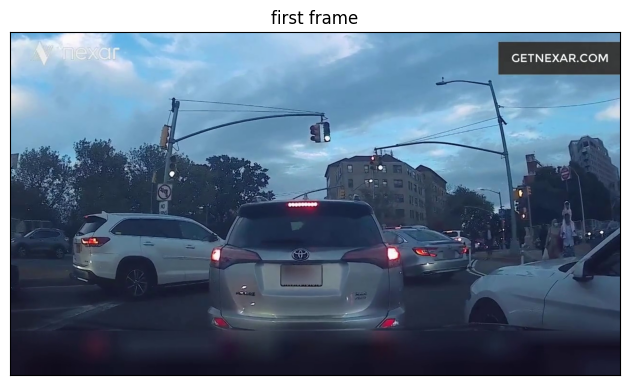

In [ ]:
plot(decoder[587], "first frame")

In [ ]:
decoder[0]

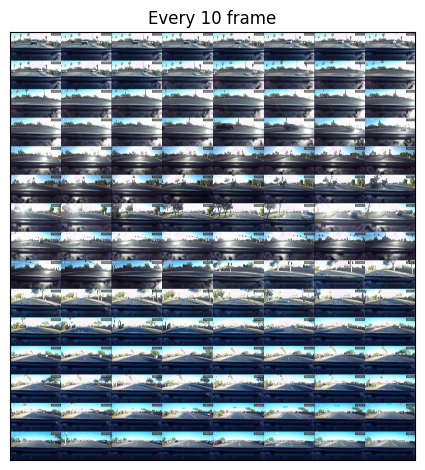

In [ ]:
every_ten_frame = decoder[0 : -1 : 10]  # using slices
plot(every_ten_frame, "Every 10 frame")

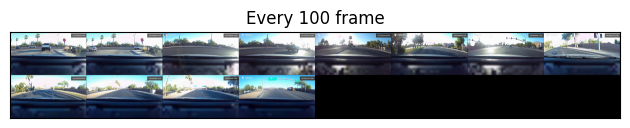

In [ ]:
every_100_frame = decoder[0 : -1 : 100]  # using slices
plot(every_100_frame, "Every 100 frame")

In [ ]:
dataset.to_pandas()

,video,time_of_event,time_of_alert,light_conditions,weather,scene,time_to_accident
0,"{'bytes': None, 'path': '/root/.cache/huggingf...",19.500,18.633,Normal,Cloudy,Urban,NaN
1,"{'bytes': None, 'path': '/root/.cache/huggingf...",19.800,19.233,Normal,Cloudy,Sub-urban,NaN
2,"{'bytes': None, 'path': '/root/.cache/huggingf...",20.101,20.068,Normal,Clear,Urban,NaN
3,"{'bytes': None, 'path': '/root/.cache/huggingf...",19.267,18.333,Normal,Clear,Urban,NaN
4,"{'bytes': None, 'path': '/root/.cache/huggingf...",21.146,18.196,Normal,Clear,Highway,NaN
...,...,...,...,...,...,...,...
1495,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Clear,Urban,NaN
1496,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Clear,Highway,NaN
1497,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Cloudy,Urban,NaN
1498,"{'bytes': None, 'path': '/root/.cache/huggingf...",NaN,NaN,Normal,Cloudy,Sub-urban,NaN


In [ ]:
frame_shape = first_frame.shape
frame_shape

torch.Size([3, 720, 1280])

In [ ]:
del every_100_frame, every_ten_frame, every_twenty_frame

## Preprocess Data

In [ ]:
max_frames = 0
min_frames = 100000
for video in dataset['video']:
  min_frames = min(min_frames, video.metadata.num_frames)
  max_frames = max(max_frames, video.metadata.num_frames)
print(min_frames)
print(max_frames)

420
1800


In [ ]:
video = dataset[0]["video"]
print(video)
frames = np.array(video)
for frame in frames:
  print(frame.shape)
  print(frame.dtype)
  print(frame.max())
  print(frame.min())
  break

(3, 720, 1280)
uint8
255
0


In [ ]:
frames.shape

(1200, 3, 720, 1280)

In [5]:
MAX_FRAMES = 32
RESIZE = (160, 160)
DURATION_TO_SELECT = 3  # 3 seconds before/after crash
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [21]:
# def get_label(example):
#     example["label"] = 1 if example["time_of_event"] is not None else 0
#     return example

# dataset = dataset.map(get_label)

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [ ]:
# def preprocess_video(sample):
#     frames, time_of_event = sample["video"], sample["time_of_event"]
#     meta = frames.metadata
#     num_frames = int(meta.num_frames)
#     duration_s = float(meta.duration_seconds)

#     fps = max(1, int(round(num_frames / duration_s))) if duration_s>0 else 30

#     # select frames
#     if time_of_event is not None:
#         center_idx = int(round(time_of_event * fps))
#         half_window = int(DURATION_TO_SELECT * fps)

#         start = max(0, center_idx - half_window)
#         end = min(num_frames, center_idx + half_window)
#         step = max(1, (end - start) // MAX_FRAMES)
#         selected = frames[start:end:step]
#     else:
#         step = max(1, num_frames // MAX_FRAMES)
#         selected = frames[0:num_frames:step]

#     np_frames = []
#     for f in selected:
#         frame = f.permute(1, 2, 0).numpy()
#         frame = cv2.resize(frame, RESIZE, interpolation=cv2.INTER_AREA)
#         frame = frame.astype(np.float32) / 255.0
#         np_frames.append(frame)

#     # pad/truncate
#     if len(np_frames) < MAX_FRAMES:
#         pad = MAX_FRAMES - len(np_frames)
#         np_frames.extend([np.zeros_like(np_frames[0])] * pad)
#     elif len(np_frames) > MAX_FRAMES:
#         np_frames = np_frames[:MAX_FRAMES]


#     sample["frames"] = np.array(np_frames, dtype=np.float32)
#     return sample

# train_ds = dataset.map(preprocess_video,batched=False,batch_size=1, keep_in_memory=False)

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [ ]:
# df = train_ds.to_pandas()
# df.to_csv('output.csv') 

In [6]:
class AccidentVideoDataset(torch.utils.data.IterableDataset):
    def __init__(self, hf_dataset, max_frames=MAX_FRAMES, resize=RESIZE):
        self.hf_dataset = hf_dataset
        self.max_frames = max_frames
        self.resize = resize

    def preprocess_video(self, frames, time_of_event):
        meta = frames.metadata
        num_frames = int(meta.num_frames)
        duration_s = float(meta.duration_seconds) 

        fps = max(1, int(round(num_frames / duration_s)))

        # select frames
        if time_of_event is not None:
            center_idx = int(round(time_of_event * fps))
            half_window = int(DURATION_TO_SELECT * fps)
            start = max(0, center_idx - half_window)
            end = min(num_frames, center_idx + half_window)
            step = max(1, (end - start) // self.max_frames)
            selected = frames[start:end:step]
        else:
            step = max(1, num_frames // self.max_frames)
            selected = frames[0:num_frames:step]

        np_frames = []
        for f in selected:
            frame = f.permute(1, 2, 0).numpy()
            frame = cv2.resize(frame, self.resize, interpolation=cv2.INTER_AREA)
            frame = frame.astype(np.float32) / 255.0
            np_frames.append(frame)

        # pad/truncate
        if len(np_frames) == 0:
            np_frames = [np.zeros((self.resize[1], self.resize[0], 3), dtype=np.float32)] * self.max_frames
        elif len(np_frames) < self.max_frames:
            pad = self.max_frames - len(np_frames)
            np_frames.extend([np.zeros_like(np_frames[0])] * pad)
        elif len(np_frames) > self.max_frames:
            np_frames = np_frames[:self.max_frames]

        frames_np = np.stack(np_frames)  # (T, H, W, 3)
        frames_np = np.transpose(frames_np, (0, 3, 1, 2))  # (T, 3, H, W)
        return torch.tensor(frames_np, dtype=torch.float32)

    def __iter__(self):
        for ex in self.hf_dataset:
            frames = ex["video"]
            time_of_event = ex.get("time_of_event", None)
            label = 1 if time_of_event is not None else 0
            frames_tensor = self.preprocess_video(frames, time_of_event)
            yield frames_tensor, torch.tensor(label, dtype=torch.long)


# Create Model

In [7]:
class CNNLSTM_EfficientNet(nn.Module):
    def __init__(self, model_name="efficientnet_b0", num_classes=2, hidden_dim=256):
        super().__init__()
        # load pretrained EfficientNet from timm
        self.cnn = timm.create_model(model_name, pretrained=True, features_only=True)
        cnn_feature_dim = self.cnn.feature_info[-1]['num_chs']

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.lstm = nn.LSTM(input_size=cnn_feature_dim,
                            hidden_size=hidden_dim,
                            num_layers=1,
                            batch_first=True)
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)
        with torch.no_grad():  # freeze EfficientNet
            feats = self.cnn(x)[-1] 
            feats = self.avgpool(feats)
            feats = feats.view(B, T, -1)
        lstm_out, _ = self.lstm(feats)
        out = lstm_out[:, -1, :]
        out = self.fc(out)
        return out


In [19]:
batch_size = 16
train_ds = AccidentVideoDataset(dataset)
train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=batch_size,
    num_workers=4,
    pin_memory=True
)

# Training

In [20]:
size_of_dataset = len(dataset)

In [ ]:
from tqdm import tqdm
model = CNNLSTM_EfficientNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss, total_correct, total = 0, 0, 0
    for videos, labels in tqdm(train_loader, total=int(size_of_dataset/batch_size)):
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * videos.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = total_correct / total
    print(f"Epoch {epoch+1}: loss={total_loss/total:.4f}, acc={acc:.3f}")


376it [1:58:17, 18.88s/it]                       


Epoch 1: loss=0.7008, acc=0.594


376it [1:57:48, 18.80s/it]                       


Epoch 2: loss=0.6088, acc=0.669


376it [1:58:15, 18.87s/it]                       


Epoch 3: loss=0.4455, acc=0.801


376it [1:55:48, 18.48s/it]                       


Epoch 4: loss=0.2159, acc=0.927


304it [1:46:10, 20.96s/it]                       